# Premise + Imported LCI (Tutorial)

**Authors**: Romain Sacchi (PSI)

**Contact**: romain.sacchi@psi.ch

## Purpose

This notebook demonstrates a realistic workflow that combines a **Premise data package**
with **user‑provided inventories** (Excel) and then runs temporal LCA, static LCA,
and climate‑emulator post‑processing (radiative forcing + temperature).

You will learn how to:

1. Load a Premise data package and reuse cached matrices.
2. Inspect the technosphere (`A`) and biosphere (`B`) matrices.
3. Select LCIA methods.
4. Import an Excel inventory and see how it integrates.
5. Run temporal routing, temporal LCA, and static LCA.
6. Plot temporal scores and link results to FaIR.

## Theory (short)

TRAILS (Temporal Routing And Aggregation of Impacts across Life‑cycle Systems)
extends classic LCA by making **time an explicit dimension**. Exchanges can carry
**temporal distributions** (discrete, normal, lognormal, uniform, triangular),
which are expanded into year offsets during traversal. For each calendar year
that becomes active, the system is solved and biosphere flows are accumulated
at their respective years. This yields **time‑resolved inventories** and **impact
scores** that answer questions like *when impacts occur* and *which upstream
suppliers dominate over time*.

**Environment requirements (from `pyproject.toml`):**
- Python `>=3.10, <3.13`
- Dependencies are loaded from `requirements.txt`
- Optional extras: `testing` (pytest), `docs` (sphinx)

**Prerequisites**
- A Premise data package (zip or directory)
- An Excel inventory file (example: `lci-pass_cars.xlsx`)


In [1]:
import logging
from pathlib import Path
from datapackage import Package

from trails import (
    Trails,
    get_lcia_method_names,
    plot_temporal_scores,
    plot_rf,
    plot_temp,
    search_activity,
    clear_cache,
)
from trails.logging import configure_trails_logging


## 1. Load the Premise data package

Update the path below to your Premise export. The first run will build and cache
matrix interpolations; later runs reuse the cache. Use `clear_cache()` if you
change the package and want a clean rebuild.


In [2]:
# Optional: clear cache to force rebuild
# clear_cache()

configure_trails_logging(file_level=logging.INFO)

# Update to your Premise package path
premise_path = Path("/Users/romain/GitHub/premise/dev/trails_2026-01-25.zip")
package = Package(str(premise_path))

trails = Trails(package, interpolate_annual=True, debug=False)


Loaded interpolated matrices from cache: /Users/romain/Library/Application Support/trails/cache/interp_f23064419269


## 2. Explore matrices and indices (A, B)

TRAILS exposes the technosphere matrix `A` and biosphere matrix `B` as 3D arrays:

- `A` indexed by `(year, activity, activity)`
- `B` indexed by `(year, activity, flow)`

These matrices are cached on first load. If you change the data package and
need a clean rebuild, call `clear_cache()` and re‑initialize `Trails`.


In [3]:
# Inspect matrix shapes (year, activity, activity) and (year, activity, flow)
print("A shape:", trails.A.shape)
print("B shape:", trails.B.shape)


A shape: (96, 39209, 39209)
B shape: (96, 39209, 9847)


In [4]:
# Coordinates include years, activities, and flows
trails.A.coords


array([[    0,     0,     0, ...,    95,    95,    95],
       [    0,     0,     0, ..., 39208, 39208, 39208],
       [    0,  4625,  5406, ..., 37784, 37797, 39208]],
      shape=(3, 46278104))

In [5]:
# Example entry: year 0, activity 0, product 0
trails.A[
    0,  # first year in the dataset
    0,  # activity 0
    0,  # product 0
]


np.float32(0.9994285)

## 3. Choose LCIA methods

Use `get_lcia_method_names` to list available methods in this package.
We keep methods in a list (order matters for static scores).


In [6]:
methods = [
    'IPCC 2021 - climate change: total (excl. biogenic CO2) - global warming potential (GWP100)',
    'IPCC 2021 (incl. biogenic CO2) - climate change: total (incl. biogenic CO2) - global warming potential (GWP100)',
]
methods


['IPCC 2021 - climate change: total (excl. biogenic CO2) - global warming potential (GWP100)',
 'IPCC 2021 (incl. biogenic CO2) - climate change: total (incl. biogenic CO2) - global warming potential (GWP100)']

## 4. Import an Excel inventory

This merges your user inventory into the existing matrices. By default,
exchanges that already exist are replaced, and new activities/flows are added.
Temporal distribution parameters (if provided in the Excel) are preserved.


In [7]:
# Example Excel inventory
trails.import_excel_inventory("lci-pass_cars.xlsx")

18:02:33+0100 [warning  ] Can't import `SimaProBlockCSVImporter` - please install `bw2io` with `pip install bw2io[multifunctional]` or install `multifunctional` and `bw_simapro_csv` manually.
Extracted 1 worksheets in 0.01 seconds
Applying strategy: csv_restore_tuples
Applying strategy: csv_restore_booleans
Applying strategy: csv_numerize
Applying strategy: csv_add_missing_exchanges_section
Applying strategy: normalize_units
Applying strategy: strip_biosphere_exc_locations
Applying strategy: set_code_by_activity_hash
Applying strategy: link_iterable_by_fields
Applying strategy: assign_only_product_as_production
Applying strategy: link_technosphere_by_activity_hash
Applying strategy: drop_falsey_uncertainty_fields_but_keep_zeros
Applying strategy: convert_uncertainty_types_to_integers
Applying strategy: convert_activity_parameters_to_list
Applied 13 strategies in 0.00 seconds


/opt/homebrew/Caskroom/miniforge/base/envs/trails/lib/python3.11/site-packages/bw2io/importers/excel.py:35: UserWarning: Invalid first cell (A1) in worksheet biomass
  warnings.warn("Invalid first cell (A1) in worksheet {}".format(sheet))
/opt/homebrew/Caskroom/miniforge/base/envs/trails/lib/python3.11/site-packages/bw2io/importers/excel.py:35: UserWarning: Invalid first cell (A1) in worksheet daccs
  warnings.warn("Invalid first cell (A1) in worksheet {}".format(sheet))


Imported Excel inventory: new_activities=2 matched_existing_activities=0 new_flows=0 matched_existing_flows=39 unlinked=0 replaced_A=rows replaced_B=rows
New activities created from import:
+-------+---------------------------------------------+---------------------------+-----------+----------+
| index |                     name                    |     reference product     |    unit   | location |
+-------+---------------------------------------------+---------------------------+-----------+----------+
| 39209 |      transport, passenger, car, diesel      | transport, passenger, car | kilometer |   RER    |
| 39210 | transport, passenger, car, battery electric | transport, passenger, car | kilometer |   RER    |
+-------+---------------------------------------------+---------------------------+-----------+----------+


{'production': 2,
 'technosphere': 18,
 'biosphere': 39,
 'new_activities': 2,
 'new_flows': 0,
 'matched_existing_activities': 0,
 'matched_existing_flows': 39,
 'unlinked': 0,
 'replaced_A': 'rows',
 'replaced_B': 'rows',
 'scenario_indices': [35, 15, 75, 95, 55, 0]}

### Notes about Excel inventory format

This Excel example file we just imported shows the `bw2io` Excel layout expected by TRAILS:

**Activity section** (field name in column A, value in column B):
- `Activity`: activity name
- `reference product`: reference product name
- `location`: location code
- `unit`: activity unit
- Any other fields

**Exchanges table** (header row starts after the `Exchanges` marker):
- `name`: exchange name
- `amount`: base exchange amount (used when no year-specific columns are provided)
- **Year-specific columns** (e.g., `2020`, `2040`, `2060`): optional numeric columns that set
  year-specific amounts. TRAILS writes these values into the corresponding years in `A`/`B` and
  linearly interpolates between them for intermediate years. Years outside the range are clamped
  to the nearest endpoint value.
- `location`: exchange location (required for technosphere/production linking)
- `categories`: biosphere categories (tuple or `compartment/subcompartment`)
- `unit`: exchange unit
- `type`: `production`, `technosphere`, or `biosphere`
- `reference product`: required for technosphere/production exchanges
- `temporal_distribution`: temporal distribution code
- `temporal_loc`: location parameter (mean/median/mode)
- `temporal_scale`: scale parameter (stddev/sigma)
- `temporal_min` / `temporal_max`: integer offset bounds
- `temporal_amount_source`: `port` (ported amount) or `matrix` (use matrix values)
- `comment`: optional notes


## 5. Explore activities and exchanges

Search for an activity, then inspect its exchanges. Use this to verify that the
imported inventory is linked as expected.


In [8]:
# Find matching activities
search_activity(trails, "transport, passenger, car,")[-5:]


index,name,reference product,location
25793,"transport, passenger, car, EURO 3, fleet average","transport, passenger, car, EURO 3, fleet average",RoW
25823,"transport, passenger, car, natural gas, small size, EURO 3","transport, passenger, car, natural gas, small size, EURO 3",RoW
25869,"transport, passenger, car, natural gas, medium size, EURO 3","transport, passenger, car, natural gas, medium size, EURO 3",RER
39209,"transport, passenger, car, diesel","transport, passenger, car",RER
39210,"transport, passenger, car, battery electric","transport, passenger, car",RER


In [9]:
# Inspect exchanges for a specific activity index
idx = 39209
trails.print_exchange_table(year=2050, act_idx=39209)

Temporal distribution codes:
+------+----------------------------+
| code |        distribution        |
+------+----------------------------+
|  1   | discrete (all mass at loc) |
|  2   |         lognormal          |
|  3   |           normal           |
|  4   |          uniform           |
|  5   |         triangular         |
+------+----------------------------+
Temporal distribution fields:
+------------------------+---------------------------------------+
|         field          |                meaning                |
+------------------------+---------------------------------------+
| temporal_distribution  |           distribution code           |
|      temporal_loc      | location parameter (mean/median/mode) |
|     temporal_scale     |     scale parameter (stddev/sigma)    |
|      temporal_min      |   minimum integer offset (inclusive)  |
|      temporal_max      |   maximum integer offset (inclusive)  |
| temporal_amount_source |         ported value or matrix      

## 6. Temporal routing and graph visualization

Routing shows how demands propagate through time. Use it to understand
long‑term dependencies before solving.


In [10]:
from trails.plotting import plot_temporal_graph

ref_year = 2050

trails.temporal_routing(
    start_year=ref_year,
    start_act_idx=idx,
    amount=1.0,
    max_depth=3,
    show_progress=True,
    attribute_to_roots=True,
)

plot_temporal_graph(
    trails,
    filename="trails_graph.html",
    notebook=False,
)


Temporal routing: 29972node [00:00, 32258.34node/s]


'trails_graph.html'

## 7. Temporal LCA (full solve)

This computes time‑resolved scores and stores the inventory for downstream
analysis (e.g., climate emulator).


In [11]:
trails.lca(
    methods=methods,
    show_progress=True,
    compute_score=True,
    store_inventory=True,
)


Temporal LCA: solve years: 100%|██████████████| 54/54 [04:23<00:00,  4.88s/year]


## 8. Static LCA (single year check)

Static LCA provides a quick single‑year benchmark for the same activity.
Scores are returned in the same order as `methods`.


In [12]:
trails.static_lca(
    year=ref_year,
    act_idx=idx,
    methods=methods,
)

static_score = trails.static_score
static_score

[46711.555105140054, 46398.40439802255]

## 9. Plot temporal scores

By default, TRAILS plots the most important contributors.


In [13]:
figs = plot_temporal_scores(
    trails=trails,
    stacked=False,
    legend_top_n=7,
    show_flow_contributions=False,
    title="",
    method_label="kg CO₂-eq",
    cumulative=False,
    width=550,
    height=450,
    year_tick=5,
    year_range=(2000, 2100),
    reference_year=ref_year,
    show_cumulative_axis=True,
    static_score=static_score,
    static_score_dash="dot",
    static_score_color="red",
)


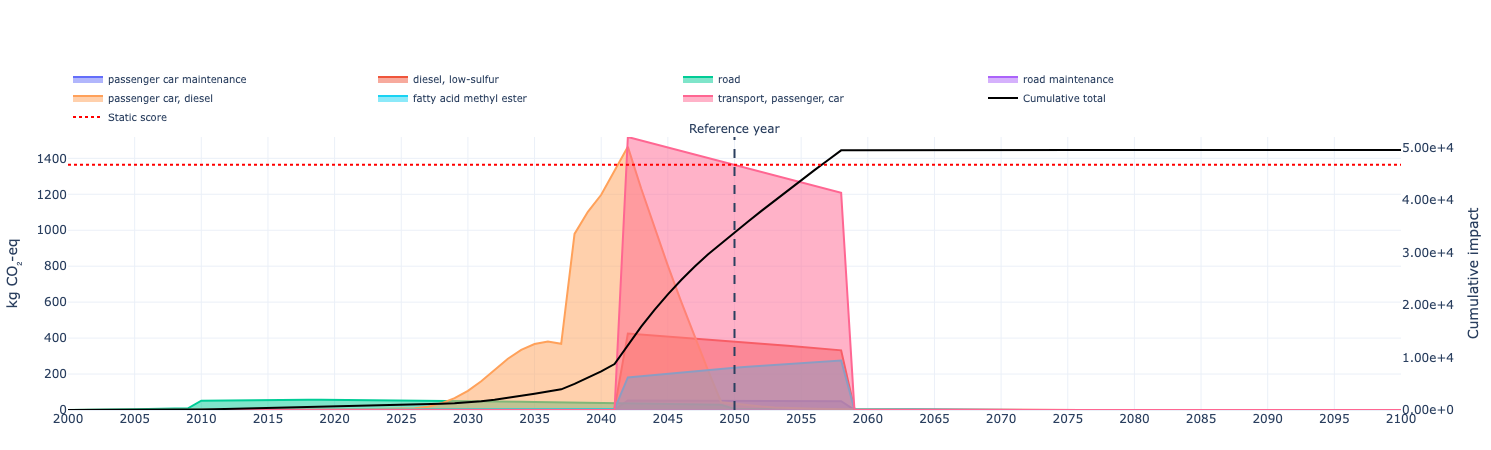

In [14]:
figs[0]

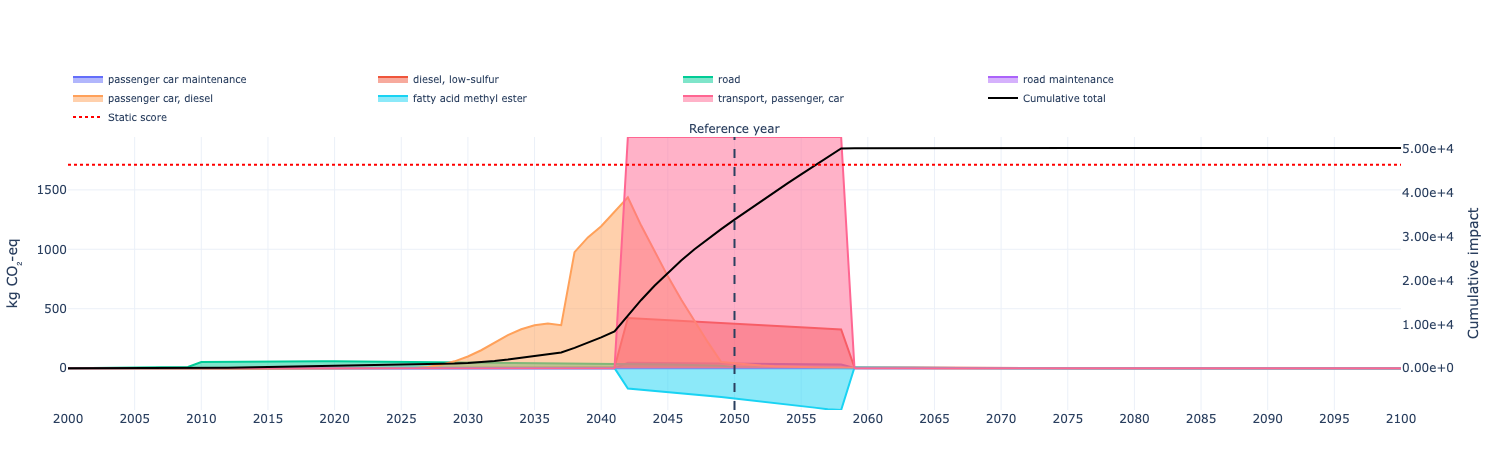

In [15]:
figs[1]

## 10. Climate emulator (FaIR)

We translate inventory time series into radiative forcing and temperature anomaly.
Results are stored as quantiles (2.5, 25, 50, 75, 97.5).


In [16]:
from trails.fair_rf import run_fair_delta_rf

rf = run_fair_delta_rf(
    trails,
    scenario="high-extension",
    scale_target_fraction=0.1,
)


/opt/homebrew/Caskroom/miniforge/base/envs/trails/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

FaIR per-species:  14%|██▌               | 2/14 [00:25<02:32, 12.68s/specie, CO]/opt/homebrew/Caskroom/miniforge/base/envs/trails/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning:

All-NaN slice encountered

FaIR per-species:  71%|███████████▍    | 10/14 [02:26<00:59, 14.78s/specie, VOC]/opt/homebrew/Caskroom/miniforge/base/envs/trails/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning:

All-NaN slice encountered

FaIR per-species:  86%|█████████████▋  | 12/14 [02:53<00:28, 14.13s/specie, NOx]/opt/homebrew/Caskroom/miniforge/base/envs/trails/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning:

All-NaN slice encountered

FaIR per-species: 100%|████████████████| 

### Plot radiative forcing and temperature


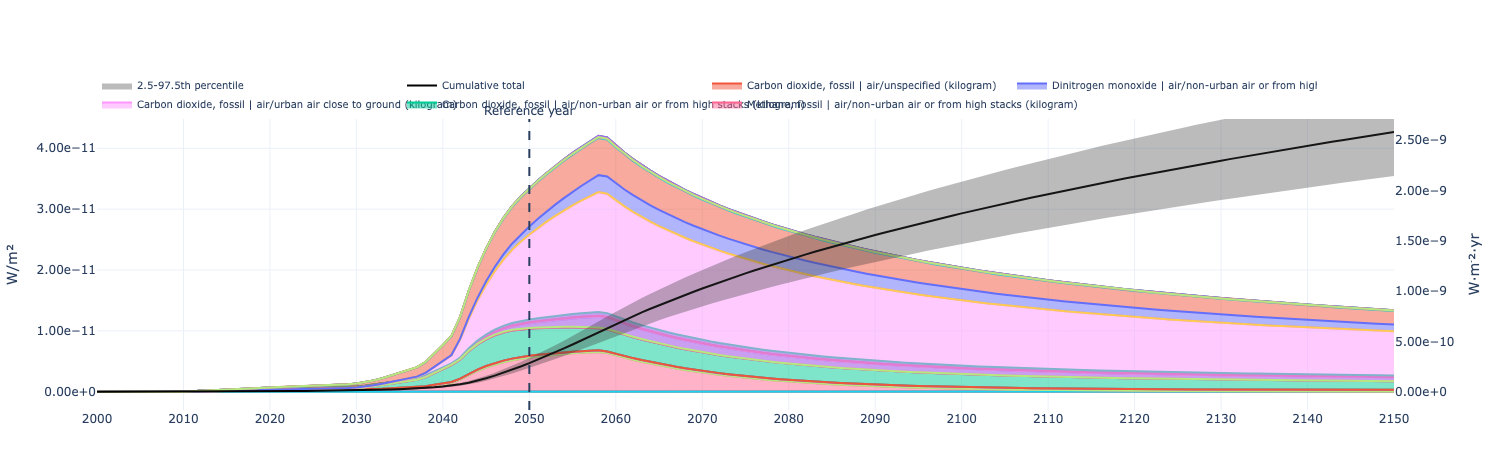

In [17]:
fig = plot_rf(
    trails=trails,
    reference_year=ref_year,
    by="flow",
    year_range=(2000, 2150),
    year_tick=10,
)
fig


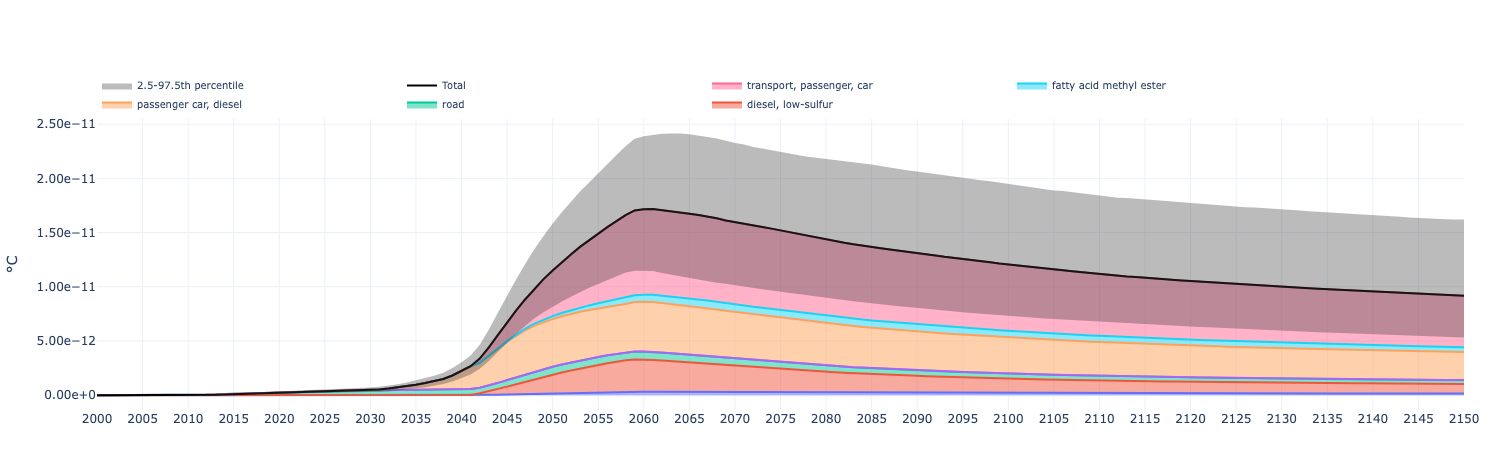

In [18]:
plot_temp(
    trails,
    by="root activity",
    title="Temperature change by root activity",
    method_label="°C",
    year_range=(2000, 2150),
)
